In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
daily_sentiment = pd.read_csv("../data/tesla_daily_sentiment.csv")
tesla_stock = pd.read_csv("../data/tesla_stock_clean.csv")

In [5]:
daily_sentiment


,Date,Avg_Sentiment
0,2021-09-30,0.116109
1,2021-10-01,0.236221
2,2021-10-02,0.514648
3,2021-10-03,0.345220
4,2021-10-04,0.116668
...,...,...
360,2022-09-25,0.166597
361,2022-09-26,0.182822
362,2022-09-27,0.287687
363,2022-09-28,0.275135


In [6]:
tesla_stock

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA
...,...,...,...,...,...,...,...,...
247,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63748400,TSLA
248,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,TSLA
249,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,TSLA
250,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,TSLA


In [8]:
daily_sentiment["Date"]=pd.to_datetime(daily_sentiment["Date"])
daily_sentiment

,Date,Avg_Sentiment
0,2021-09-30,0.116109
1,2021-10-01,0.236221
2,2021-10-02,0.514648
3,2021-10-03,0.345220
4,2021-10-04,0.116668
...,...,...
360,2022-09-25,0.166597
361,2022-09-26,0.182822
362,2022-09-27,0.287687
363,2022-09-28,0.275135


In [10]:
tesla_stock["Date"] =pd.to_datetime(tesla_stock["Date"])
tesla_stock

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA
...,...,...,...,...,...,...,...,...
247,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63748400,TSLA
248,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,TSLA
249,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,TSLA
250,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,TSLA


In [11]:
print(f"Sentiment row: {len(daily_sentiment)}")
print(f"Stock rows:{len(tesla_stock)}")
print(f"\n Sentiment data range: {daily_sentiment['Date'].min()} to {daily_sentiment['Date'].max()}")
print(f"Stock date range: {tesla_stock['Date'].min()} to {tesla_stock['Date'].max()}")

Sentiment row: 365
Stock rows:252

 Sentiment data range: 2021-09-30 00:00:00 to 2022-09-29 00:00:00
Stock date range: 2021-09-30 00:00:00 to 2022-09-29 00:00:00


#### Task1: Add Stock movement columns 

In [14]:
# Sort by date
tesla_stock = tesla_stock.sort_values("Date").reset_index(drop=True)
tesla_stock

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA
...,...,...,...,...,...,...,...,...
247,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63748400,TSLA
248,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,TSLA
249,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,TSLA
250,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,TSLA


In [16]:
#Daily return - how much price changed each day in percentage
tesla_stock["Daily_Return"] = tesla_stock["Close"].pct_change() * 100
tesla_stock

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,Daily_Return
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA,NaN
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA,-0.033529
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA,0.813962
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA,-0.120285
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA,0.276714
...,...,...,...,...,...,...,...,...,...
247,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63748400,TSLA,-4.594757
248,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,TSLA,0.246985
249,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,TSLA,2.510776
250,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,TSLA,1.721211


In [18]:
# Price direction - did it go up or down
tesla_stock["Direction"] = tesla_stock["Daily_Return"].apply(
    lambda x: "Up" if x>0 else "Down"
)
tesla_stock

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,Daily_Return,Direction
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA,NaN,Down
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA,-0.033529,Down
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA,0.813962,Up
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA,-0.120285,Down
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA,0.276714,Up
...,...,...,...,...,...,...,...,...,...,...
247,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63748400,TSLA,-4.594757,Down
248,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,TSLA,0.246985,Up
249,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,TSLA,2.510776,Up
250,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,TSLA,1.721211,Up


In [19]:
# Next day return - did price go up Tomorrow
# We want to know if today's sentiment predicts the tomorrow's price 
tesla_stock["Next_Day_Return"] = tesla_stock["Daily_Return"].shift(-1)
tesla_stock

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,Daily_Return,Direction,Next_Day_Return
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA,NaN,Down,-0.033529
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA,-0.033529,Down,0.813962
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA,0.813962,Up,-0.120285
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA,-0.120285,Down,0.276714
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA,0.276714,Up,1.387426
...,...,...,...,...,...,...,...,...,...,...,...
247,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63748400,TSLA,-4.594757,Down,0.246985
248,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,TSLA,0.246985,Up,2.510776
249,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,TSLA,2.510776,Up,1.721211
250,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,TSLA,1.721211,Up,-6.810050


#### Task2: Merge sentiment with stock data

In [23]:
merged = pd.merge(tesla_stock, daily_sentiment, on="Date", how="inner")
merged.drop(columns=['Stock Name'], inplace=True)
print(f"Merged rows: {len(merged)}")
print(f"Columns: {merged.columns.tolist()}")
print(merged.head())

Merged rows: 252
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return', 'Direction', 'Next_Day_Return', 'Avg_Sentiment']
        Date        Open        High         Low       Close   Adj Close  \
0 2021-09-30  260.333344  263.043335  258.333344  258.493347  258.493347   
1 2021-10-01  259.466675  260.260010  254.529999  258.406677  258.406677   
2 2021-10-04  265.500000  268.989990  258.706665  260.510010  260.510010   
3 2021-10-05  261.600006  265.769989  258.066681  260.196655  260.196655   
4 2021-10-06  258.733337  262.220001  257.739990  260.916656  260.916656   

     Volume  Daily_Return Direction  Next_Day_Return  Avg_Sentiment  
0  53868000           NaN      Down        -0.033529       0.116109  
1  51094200     -0.033529      Down         0.813962       0.236221  
2  91449900      0.813962        Up        -0.120285       0.116668  
3  55297800     -0.120285      Down         0.276714       0.144453  
4  43898400      0.276714        Up   

In [25]:
merged = merged.dropna(subset=["Daily_Return","Next_Day_Return","Avg_Sentiment"])
print(f"After dropping NaN:{len(merged)} rows")


After dropping NaN:250 rows


In [31]:
merged.to_csv("../data/tesla_merged.csv", index=False)
print("Saved")
merged.head()

Saved


,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Direction,Next_Day_Return,Avg_Sentiment
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,-0.033529,Down,0.813962,0.236221
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,0.813962,Up,-0.120285,0.116668
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,-0.120285,Down,0.276714,0.144453
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,0.276714,Up,1.387426,0.164024
5,2021-10-07,261.820007,268.333344,261.126678,264.536682,264.536682,57587400,1.387426,Up,-1.023183,0.343725


#### Task3: Correlation analysis

In [27]:
# Correlation between sentiment and same day return
same_day_corr = merged["Avg_Sentiment"].corr(merged["Daily_Return"])
print(f"Same day correlation :  {same_day_corr:.4f}")

Same day correlation :  0.4510


In [29]:
# Correlation between sentiment and Next day return
next_day_corr = merged["Avg_Sentiment"].corr(merged["Next_Day_Return"])
print(f"Next day correlation :  {next_day_corr:.4f}")

Next day correlation :  -0.0377


In [34]:
# What does this mean

print(f"\nInterpretation :")
if abs(same_day_corr) > 0.3:
    print(f"Strong same-day relationship")
elif abs(same_day_corr)>0.1:
    print(f"Weak same-day relationship")
else:
    print(f"No meaningful same-day relationship")

if abs(next_day_corr)>0.3:
    print(f"Sentiment PREDICTS next day price")
elif abs(next_day_corr)>0.1:
    print(f"Weak predictive signal")
else:
    print(f"Sentiment does NOT predict next day price")
    


Interpretation :
Strong same-day relationship
Sentiment does NOT predict next day price


#### Task4: Visualize correlation

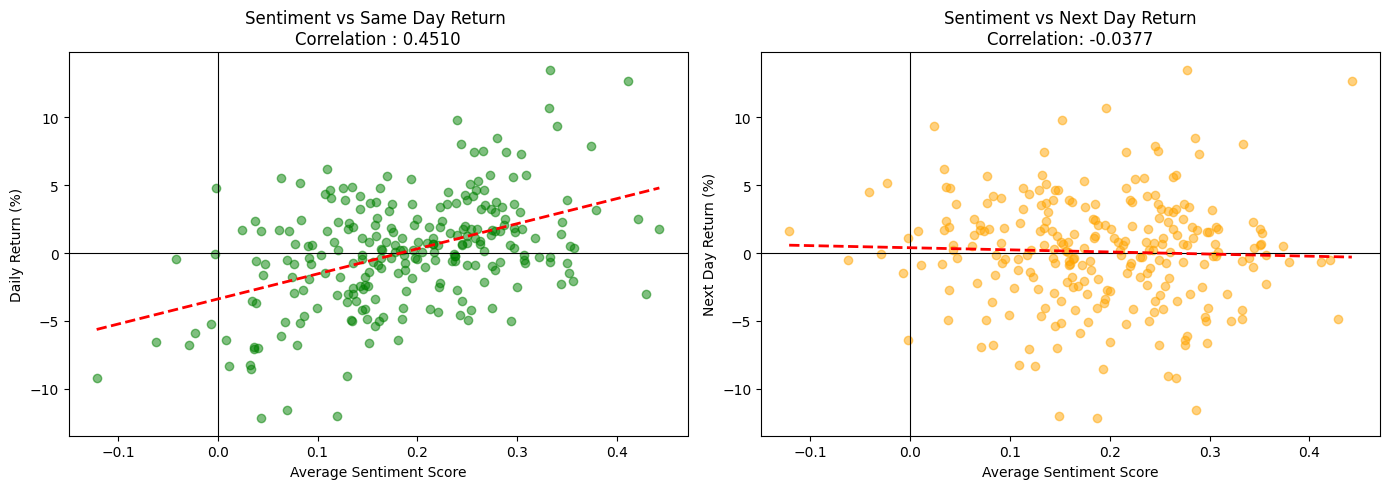

In [43]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
#plot 1
axes[0].scatter(merged["Avg_Sentiment"], merged["Daily_Return"],alpha=0.5,color="green")
axes[0].axhline(y=0, color="black", linewidth=0.8)
axes[0].axvline(x=0,color="black", linewidth=0.8)
axes[0].set_xlabel("Average Sentiment Score")
axes[0].set_ylabel("Daily Return (%)")
axes[0].set_title(f"Sentiment vs Same Day Return \nCorrelation : {same_day_corr:.4f}")

#add trendline
z = np.polyfit(merged["Avg_Sentiment"],merged["Daily_Return"],1)
p = np.poly1d(z)
axes[0].plot(sorted(merged["Avg_Sentiment"]),p(sorted(merged["Avg_Sentiment"])),"r--", linewidth=2)


#plot2
axes[1].scatter(merged["Avg_Sentiment"], merged["Next_Day_Return"],
                alpha=0.5, color="orange")
axes[1].axhline(y=0, color="black", linewidth=0.8)
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_xlabel("Average Sentiment Score")
axes[1].set_ylabel("Next Day Return (%)")
axes[1].set_title(f"Sentiment vs Next Day Return\nCorrelation: {next_day_corr:.4f}")

z2 = np.polyfit(merged["Avg_Sentiment"].dropna(),
                merged["Next_Day_Return"].dropna(), 1)
p2 = np.poly1d(z2)
axes[1].plot(sorted(merged["Avg_Sentiment"]),
             p2(sorted(merged["Avg_Sentiment"])),
             "r--", linewidth=2)

plt.tight_layout()
plt.show()

#### Task5: Sentiment vs Stock price over time

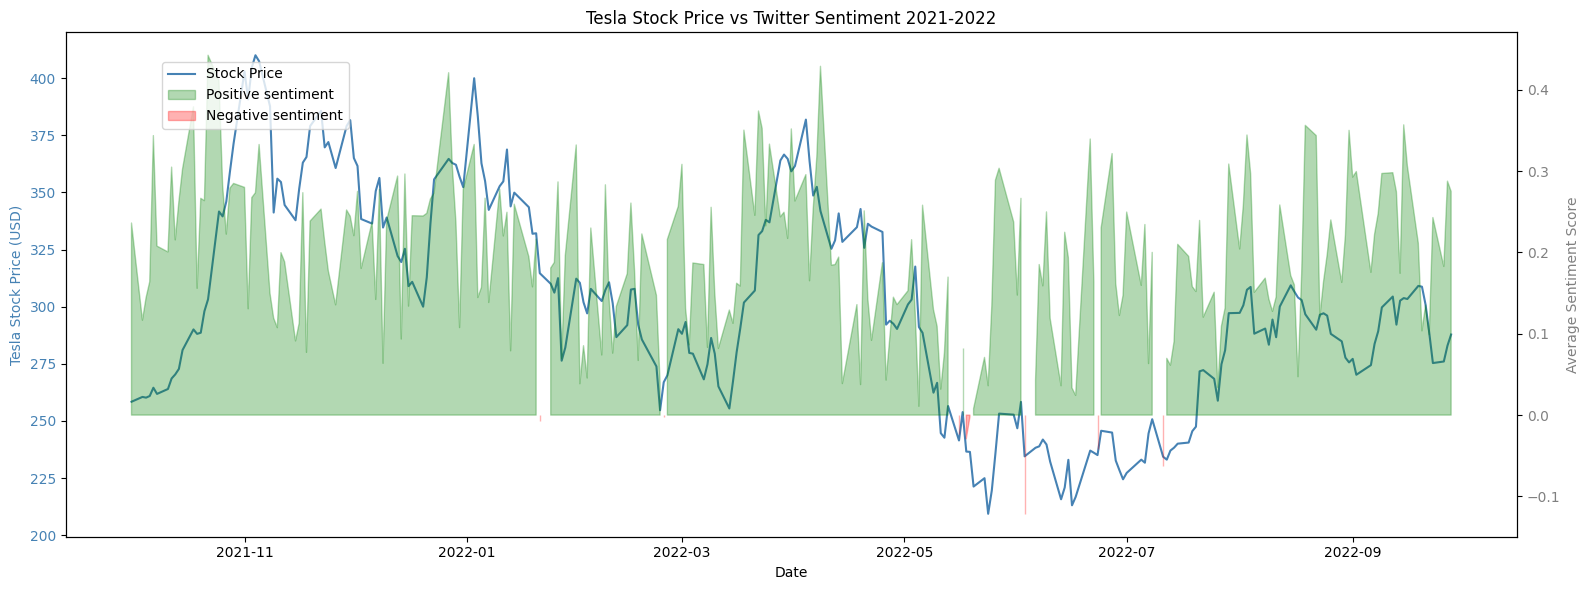

In [44]:
fig, ax1 = plt.subplots(figsize=(16, 6))

# Plot stock price on left axis
ax1.plot(merged["Date"], merged["Close"],
         color="steelblue", linewidth=1.5, label="Stock Price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Tesla Stock Price (USD)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Plot sentiment on right axis
ax2 = ax1.twinx()
ax2.fill_between(merged["Date"], merged["Avg_Sentiment"], 0,
                 where=merged["Avg_Sentiment"] > 0,
                 color="green", alpha=0.3, label="Positive sentiment")
ax2.fill_between(merged["Date"], merged["Avg_Sentiment"], 0,
                 where=merged["Avg_Sentiment"] < 0,
                 color="red", alpha=0.3, label="Negative sentiment")
ax2.set_ylabel("Average Sentiment Score", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

plt.title("Tesla Stock Price vs Twitter Sentiment 2021-2022")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

#### Task6: High vs Low sentiment days

In [49]:
high_sentiment =  merged[merged["Avg_Sentiment"]>0.1]["Next_Day_Return"]
low_sentiment = merged[merged["Avg_Sentiment"]<-0.1]["Next_Day_Return"]
neutral = merged[(merged["Avg_Sentiment"] >= -0.1) & (merged["Avg_Sentiment"] <= 0.1)]["Next_Day_Return"]


print(" Average next day return by sentiment: ")
print(f"High sentiment days:    {high_sentiment.mean():.2f}%")
print(f"Neutral sentiment days: {neutral.mean():.2f}%")
print(f"Low sentiment days:     {low_sentiment.mean():.2f}%")


 Average next day return by sentiment: 
High sentiment days:    -0.03%
Neutral sentiment days: 0.65%
Low sentiment days:     1.60%


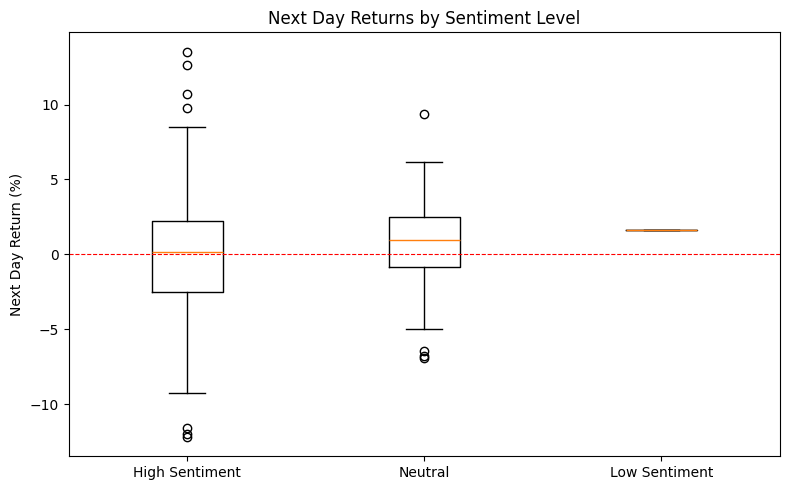

In [50]:
plt.figure(figsize=(8, 5))
plt.boxplot([high_sentiment.dropna(),
             neutral.dropna(),
             low_sentiment.dropna()],
            labels=["High Sentiment", "Neutral", "Low Sentiment"])
plt.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
plt.title("Next Day Returns by Sentiment Level")
plt.ylabel("Next Day Return (%)")
plt.tight_layout()
plt.show()

In [51]:
# Add sentiment category column
merged["Sentiment_Category"] = pd.cut(
    merged["Avg_Sentiment"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["Negative", "Neutral", "Positive"]
)

# Save for Power BI
merged.to_csv("../data/tesla_final.csv", index=False)
print("Final dataset saved!")
print(f"\nFinal shape: {merged.shape}")
print(merged.columns.tolist())

Final dataset saved!

Final shape: (250, 12)
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return', 'Direction', 'Next_Day_Return', 'Avg_Sentiment', 'Sentiment_Category']
